In [ ]:
import pandas as pd, numpy as np
import seaborn as sns, matplotlib.pyplot as plt
import json

with open('/home/maxwshen/piu-annotate/artifacts/chartstructs/main/lgbm-120524/page-content/chart-table.json', 'rb') as f:
    d = json.load(f)
    

In [2]:
df = pd.DataFrame(d)
df.columns

Index(['name', 'sord', 'level', 'pack', 'skills', 'NPS', 'BPM info',
       'Sustain time'],
      dtype='object')

In [3]:
df['Sustain time (capped)'] = np.clip(np.array(df['Sustain time']), 0, 50)

df['Sustain time (capped)'].describe()

count    4294.000000
mean       16.433628
std        10.726494
min         0.000000
25%         8.000000
50%        14.000000
75%        22.000000
max        50.000000
Name: Sustain time (capped), dtype: float64

### NPS and Sustain Time by Level

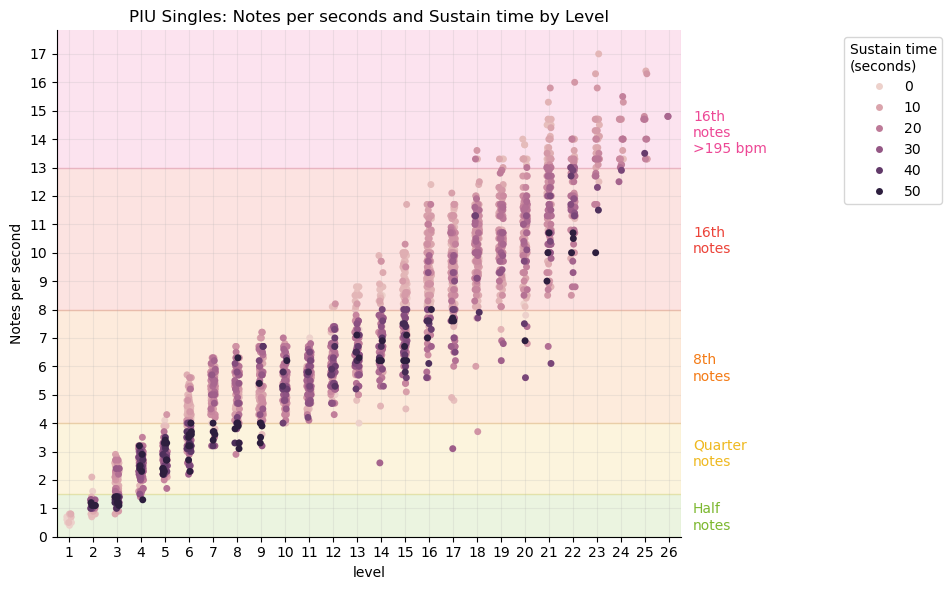

In [92]:
fig, ax = plt.subplots(figsize = (10, 6))

sns.stripplot(
    x = 'level',
    y = 'NPS',
    data = df[df['sord'] == 'singles'].sort_values(by = 'Sustain time (capped)'),
    # alpha = 0.2,
    hue = 'Sustain time (capped)',
    ax = ax,
)
plt.legend(title = 'Sustain time\n(seconds)', bbox_to_anchor = (1.25, 1))
sns.despine()
plt.ylabel('Notes per second')
plt.title('PIU Singles: Notes per seconds and Sustain time by Level');

plt.yticks(np.arange(0, 18, 1));
plt.ylim(bottom = 0)
alpha = 0.15
plt.axhspan(0, 1.5, color='#7cb82f', alpha=alpha)
plt.axhspan(1.5, 4, color='#efb920', alpha=alpha)
plt.axhspan(4, 8, color='#f47b16', alpha=alpha)
plt.axhspan(8, 13, color='#ec4339', alpha=alpha)
plt.axhspan(13, 18, color='#ed4795', alpha=alpha)
plt.text(26, 0.25, 'Half\nnotes', fontdict = {'color': '#7cb82f'});
plt.text(26, 2.5, 'Quarter\nnotes', fontdict = {'color': '#efb920'});
plt.text(26, 5.5, '8th\nnotes', fontdict = {'color': '#f47b16'});
plt.text(26, 10, '16th\nnotes', fontdict = {'color': '#ec4339'});
plt.text(26, 13.5, '16th\nnotes\n>195 bpm', fontdict = {'color': '#ed4795'});
plt.grid(alpha = 0.2, markevery = (1, 1))

plt.tight_layout()
plt.savefig('piu-singles-nps-sustain-level.png', dpi = 300)

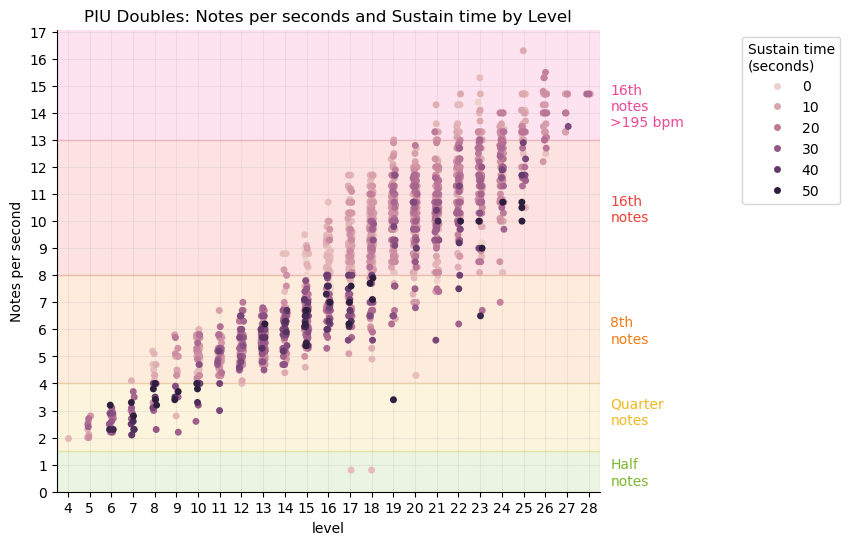

In [68]:
fig, ax = plt.subplots(figsize = (7, 6))

sns.stripplot(
    x = 'level',
    y = 'NPS',
    data = df[df['sord'] == 'doubles'].sort_values(by = 'Sustain time (capped)'),
    # alpha = 0.2,
    hue = 'Sustain time (capped)',
    ax = ax,
)
plt.legend(title = 'Sustain time\n(seconds)', bbox_to_anchor = (1.25, 1))
sns.despine()
plt.ylabel('Notes per second')
plt.title('PIU Doubles: Notes per seconds and Sustain time by Level');

plt.yticks(np.arange(0, 18, 1));
plt.ylim(bottom = 0)
alpha = 0.15
plt.axhspan(0, 1.5, color='#7cb82f', alpha=alpha)
plt.axhspan(1.5, 4, color='#efb920', alpha=alpha)
plt.axhspan(4, 8, color='#f47b16', alpha=alpha)
plt.axhspan(8, 13, color='#ec4339', alpha=alpha)
plt.axhspan(13, 18, color='#ed4795', alpha=alpha)
plt.text(25, 0.25, 'Half\nnotes', fontdict = {'color': '#7cb82f'});
plt.text(25, 2.5, 'Quarter\nnotes', fontdict = {'color': '#efb920'});
plt.text(25, 5.5, '8th\nnotes', fontdict = {'color': '#f47b16'});
plt.text(25, 10, '16th\nnotes', fontdict = {'color': '#ec4339'});
plt.text(25, 13.5, '16th\nnotes\n>195 bpm', fontdict = {'color': '#ed4795'});
plt.grid(alpha = 0.2, markevery = (1, 1))


### sorted stats

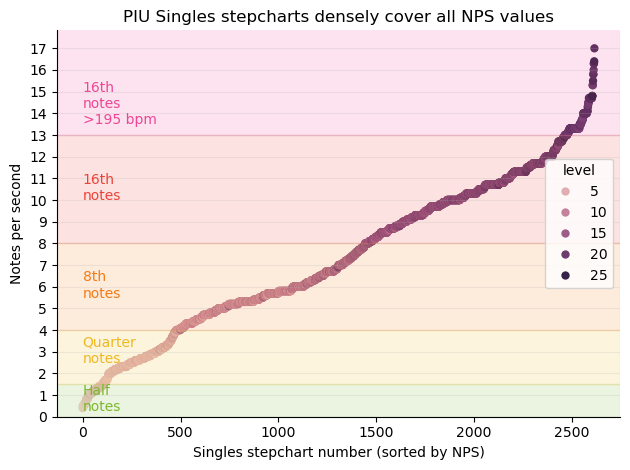

In [120]:
# fig, ax = plt.subplots(figsize = (10, 6))

stat = 'NPS'
dfs = df.query('sord=="singles"').sort_values(by = stat).reset_index(drop = True).copy()

sns.scatterplot(
    x = dfs.index,
    y = stat,
    data = dfs,
    linewidth = 0,
    hue = 'level',
    # ax = ax,
)
# plt.legend(title = 'Sustain time\n(seconds)', bbox_to_anchor = (1.25, 1))
sns.despine()
plt.ylabel('Notes per second')
plt.xlabel('Singles stepchart number (sorted by NPS)');
plt.title('PIU Singles stepcharts densely cover all NPS values');

plt.yticks(np.arange(0, 18, 1));
plt.ylim(bottom = 0)

alpha = 0.15
plt.axhspan(0, 1.5, color='#7cb82f', alpha=alpha)
plt.axhspan(1.5, 4, color='#efb920', alpha=alpha)
plt.axhspan(4, 8, color='#f47b16', alpha=alpha)
plt.axhspan(8, 13, color='#ec4339', alpha=alpha)
plt.axhspan(13, 18, color='#ed4795', alpha=alpha)
plt.text(0, 0.25, 'Half\nnotes', fontdict = {'color': '#7cb82f'});
plt.text(0, 2.5, 'Quarter\nnotes', fontdict = {'color': '#efb920'});
plt.text(0, 5.5, '8th\nnotes', fontdict = {'color': '#f47b16'});
plt.text(0, 10, '16th\nnotes', fontdict = {'color': '#ec4339'});
plt.text(0, 13.5, '16th\nnotes\n>195 bpm', fontdict = {'color': '#ed4795'});

plt.grid(axis = 'y', alpha = 0.2)

plt.tight_layout()
plt.savefig('piu-singles-sorted-nps.png', dpi = 300)

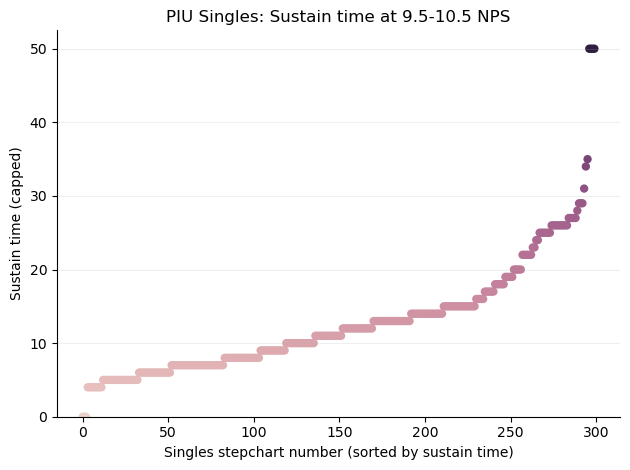

In [135]:
# fig, ax = plt.subplots(figsize = (10, 6))

stat = 'Sustain time (capped)'
dfs = df.query('sord=="singles" and NPS.between(9.5, 10.5)').sort_values(by = stat).reset_index(drop = True).copy()

sns.scatterplot(
    x = dfs.index,
    y = stat,
    data = dfs,
    linewidth = 0,
    # hue = 'level',
    hue = 'Sustain time (capped)'
    # ax = ax,
)
# plt.legend(title = 'Sustain time\n(seconds)', bbox_to_anchor = (1.25, 1))
plt.legend().remove()
sns.despine()
# plt.ylabel('Notes per second')
plt.xlabel('Singles stepchart number (sorted by sustain time)');
plt.title('PIU Singles: Sustain time at 9.5-10.5 NPS');

# plt.yticks(np.arange(0, 18, 1));
plt.ylim(bottom = 0)

alpha = 0.15
# plt.axhspan(0, 1.5, color='#7cb82f', alpha=alpha)
# plt.axhspan(1.5, 4, color='#efb920', alpha=alpha)
# plt.axhspan(4, 8, color='#f47b16', alpha=alpha)
# plt.axhspan(8, 13, color='#ec4339', alpha=alpha)
# plt.axhspan(13, 18, color='#ed4795', alpha=alpha)
# plt.text(0, 0.25, 'Half\nnotes', fontdict = {'color': '#7cb82f'});
# plt.text(0, 2.5, 'Quarter\nnotes', fontdict = {'color': '#efb920'});
# plt.text(0, 5.5, '8th\nnotes', fontdict = {'color': '#f47b16'});
# plt.text(0, 10, '16th\nnotes', fontdict = {'color': '#ec4339'});
# plt.text(0, 13.5, '16th\nnotes\n>195 bpm', fontdict = {'color': '#ed4795'});

plt.grid(axis = 'y', alpha = 0.2)

plt.tight_layout()
plt.savefig('piu-singles-sorted-sustain_time-10nps.png', dpi = 300)

### Pareto frontier

In [69]:
import pandas as pd

def select_pareto_frontier(
    df: pd.DataFrame, 
    col1: str, 
    col2: str, 
    col1_pickup_width: float, 
    col2_pickup_width: float,
) -> pd.DataFrame:
    """ Returns subset dataframe of selected points near pareto frontier,
        prioritizing higher values of col1, then higher values of col2.
        Picks up points "close" to pareto frontier, within col1/2_pickup_width. 
    """
    import itertools, copy
    
    def keep_efficient(pts):
        """ returns Pareto efficient row subset of pts """
        pts = pts[pts.sum(1).argsort()[::-1]]
        undominated = np.ones(pts.shape[0], dtype=bool)
        for i in range(pts.shape[0]):
            n = pts.shape[0]
            if i >= n:
                break
            undominated[i+1:n] = (pts[i+1:] >= pts[i]).any(1) 
            pts = pts[undominated[:n]]
            undominated = np.array([True]*len(pts))
        return pts

    pts = df[[col1, col2]].replace(np.nan, -np.inf).to_numpy()
    tpl_pts = [tuple(pt) for pt in pts]
    if len(set(tpl_pts)) != len(tpl_pts):
        print('WARNING: this code does not handle duplicates correctly')
    eff_pts = sorted([tuple(pt) for pt in keep_efficient(pts)], reverse = True)

    # indices of efficient pts
    select_idxs = sorted(list(set([tpl_pts.index(pt) for pt in eff_pts])))
    sel_df = df.iloc[select_idxs]
    chosen_pts = copy.copy(eff_pts)

    def dominates(a, b, c):
        """ Returns whether point c dominates pareto line from a-b
            (c is to the right of line from a-b)
        """ 
        x = lambda pt: pt[0]
        y = lambda pt: pt[1]
        return (x(b) - x(a))*(y(c) - y(a)) - (y(b) - y(a))*(x(c) - x(a)) < 0

    for ep1, ep2 in itertools.pairwise(eff_pts):
        crit1 = (df[col1] >= ep2[0] - col1_pickup_width)
        crit2 = (df[col2] >= ep1[1] - col2_pickup_width)
        dfs = df[crit1 & crit2]

        for idx, row in dfs.iterrows():
            query_x = row[col1] + col1_pickup_width
            query_y = row[col2] + col2_pickup_width
            pt = (row[col1], row[col2])
            if dominates(ep1, ep2, (query_x, query_y)):
                if pt not in chosen_pts:
                    chosen_pts.append(pt)
                    sel_df = pd.concat([sel_df, pd.DataFrame(row).T])
    return sel_df

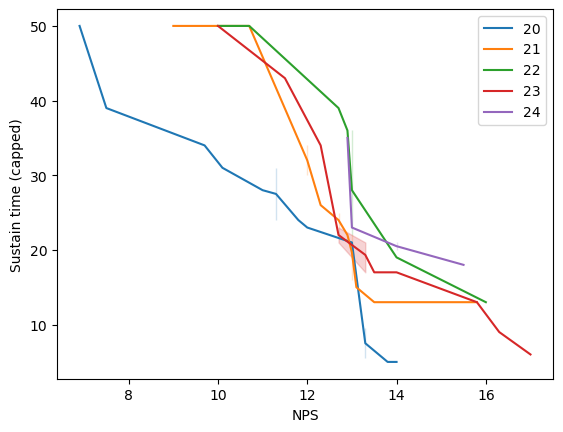

In [74]:
for level in range(20, 24 + 1):
    dfs = select_pareto_frontier(
        df.query('sord=="singles" and level==@level'),
        'NPS',
        'Sustain time (capped)',
        0, 0
    )
    sns.lineplot(
        x = 'NPS', 
        y = 'Sustain time (capped)', 
        data = dfs,
        label = level,
    )

<Axes: xlabel='Sustain time (capped)', ylabel='NPS'>

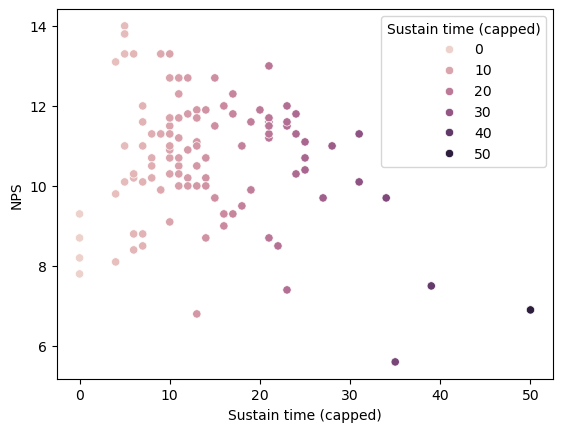

In [14]:
sns.scatterplot(
    x = 'Sustain time (capped)',
    y = 'NPS',
    data = df.query('sord=="singles" and level==20'),
    # alpha = 0.2,
    hue = 'Sustain time (capped)',
)

### exploratory

<Axes: xlabel='level', ylabel='NPS'>

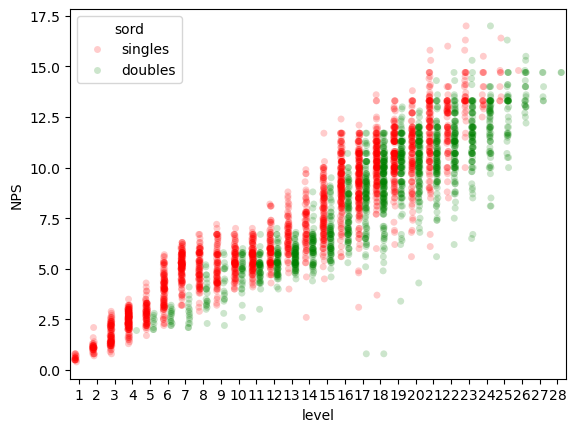

In [29]:
sns.stripplot(
    x = 'level',
    y = 'NPS',
    data = df,
    dodge = True,
    palette = {
        'singles': 'red',
        'doubles': 'green',
    },
    alpha = 0.2,
    hue = 'sord',
)

/tmp/ipykernel_23343/3387882382.py:1: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


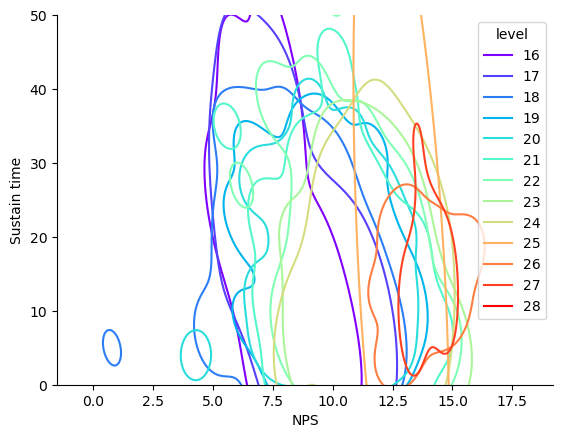

In [37]:
sns.kdeplot(
    x = 'NPS',
    y = 'Sustain time',
    data = df[(df['level'] >= 16) & (df['sord'] == 'doubles')],
    hue = 'level',
    palette = 'rainbow',
    levels = 1,
)
plt.ylim(bottom = 0, top = 50)
sns.despine()
# plt.grid(alpha = 0.3)